# Rigid sphere — Mesh2HRTF check

## Hard Sphere (`Sphere_20cm`) — single reciprocal source

**Stéphane Dedieu** · Bloo Audio Inc. · Ottawa  
**17 September 2026**


Ico-4, $a=0.10\,\mathrm{m}$, $c=346.18\,\mathrm{m/s}$.
Reciprocal point source $2\,\mathrm{mm}$ off the skin.
Compare $|p|$ at $10\,\mathrm{m}$ ($0^\circ$–$180^\circ$) with Morse.

This notebook only **loads** `ObjectMeshes/Reference` and
`NumCalc/source_*/be.out`, then plots. 

Project folder: `ICO_Sphere_HD20cm_sol10m_point_source_v1`  <br>
Working standoff: $x=0.102\,\mathrm{m}$.  `source_1` <br>
Working standoff: $x=0.101\,\mathrm{m}$.  `source_2`

Solver: NumCalc (Mesh2HRTF 1.3.0), Burton–Miller BEM + FMM  
Grid: `EvaluationGrids/UV_Sphere_10m` — **r = 10 m** sphere, 1850 points  


Computed band: 50 Hz – 8 kHz (50 Hz steps)

Sanity-check notebook: read the nodes, 3D scatter, then relative 20log10⁡|p| maps.

## Introduction

This notebook post-processes Mesh2HRTF / NumCalc runs (Burton–Miller BEM, ML-FMM) on a rigid sphere of radius a = 0.1 m.
One reciprocal point source sits on +x, at 1 mm or 2 mm off the skin: (0.101, 0, 0) m and (0.102, 0, 0) m.

Pressure is read at 10 m. By reciprocity this is compared with the analytical plane-wave solution of Morse on the same sphere.

The notebook loads the mesh, the source position, and |p| at 0°, 30°, 60°, 90°, 120°, 150° and 180°.


## How to run the simulation. 

The folders `\ICO_Sphere_HD20cm_sol10m_point_source_v1\NumCalc\source_1` … `source_2`  **contain no results**. Only the input file `NC.inp` is there. <br>
**Run the simulation as described below before post-processing with the Notebook**.

NumCalc is a Unix binary. On Windows, install **WSL2** with Ubuntu 22.04 and open that terminal (not PowerShell). <br>
In the Ubuntu window, for each subfolder `source_1` , `source_2` run the following commands:

```bash
cd .../ICO_Sphere_HD20cm_sol10m_point_source_v1/NumCalc/source_1    
.../Mesh2HRTF-1.3.0/mesh2hrtf/NumCalc/bin/NumCalc   -istart 1  -iend 160  -nitermax 500
```
160 frequencies: 50:50:8000 Hz

## Conclusions

There is a small low-frequency bias (about $0.3\,\mathrm{dB}$ magnitude spread at $ka\approx 0.18$). We are still tuning NumCalc; other FMM and
quadrature knobs will be tried.

With the present settings — Ico-4, $2\,\mathrm{mm}$ source, cluster $0.1\,\mathrm{m}$ — the far-field TFs sit close enough to Morse for array work. Mesh2HRTF is solid in $50\,\mathrm{Hz}$–$8\,\mathrm{kHz}$.


###  Pressure on Boundary 

In [ ]:
from pathlib import Path
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio


ref = Path(r".\ICO_Sphere_HD20cm_sol10m_point_source_v1\ObjectMeshes\Reference")
p_path = Path(r".\ICO_Sphere_HD20cm_sol10m_point_source_v1\NumCalc\source_1\be.out\be.20\pBoundary")

nraw = (ref / "Nodes.txt").read_text().strip().splitlines()
nodes = np.loadtxt(nraw[1:])
nid, xyz = nodes[:, 0].astype(int), nodes[:, 1:4]
imap = {int(i): k for k, i in enumerate(nid)}

eraw = (ref / "Elements.txt").read_text().strip().splitlines()
elems = np.loadtxt(eraw[1:], dtype=int)
tri = np.array([[imap[int(a)], imap[int(b)], imap[int(c)]]
                for a, b, c in elems[:, 1:4]])
eids = elems[:, 0].astype(int)

praw = p_path.read_text().strip().splitlines()
# 3 lignes header, puis "id Re Im" par ELEMENT
pdata = np.loadtxt(praw[3:])
pid, pre, pim = pdata[:, 0].astype(int), pdata[:, 1], pdata[:, 2]
mag = np.hypot(pre, pim)

# aligner p[k] = pression de l'element eids[k]
pmap = {int(i): m for i, m in zip(pid, mag)}
face_p = np.array([pmap[int(e)] for e in eids])
face_db = 20.0 * np.log10(np.maximum(face_p, 1e-30) / np.max(face_p))

fig = go.Figure(data=[go.Mesh3d(
    x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
    i=tri[:, 0], j=tri[:, 1], k=tri[:, 2],
    intensity=face_db,
    intensitymode="cell",          # une couleur par triangle
    colorscale="Jet",
    colorbar=dict(title="dB re max"),
    flatshading=True,
)])
fig.update_layout(
    title="pBoundary |p| @ ~1 kHz — source_2 / elem 1014",
    width=1100, height=800,
    scene=dict(aspectmode="data",
               xaxis_title="X", yaxis_title="Y", zaxis_title="Z"),
)
pio.renderers.default = "browser"
fig.show(renderer="notebook")
#fig.show()
print("faces", len(face_db), "dB min/max", face_db.min(), face_db.max())

###  Sphere 20 cm HD  far field 10 meters      Test Cluster radius

####   Point source at 2-mm from the surface - (x,y,z)=(0.102,0,0) m

889
0 deg  gid 200889 xyz [10.  0.  0.]
895
30 deg  gid 200895 xyz [8.66025404 5.         0.        ]
901
60 deg  gid 200901 xyz [5.         8.66025404 0.        ]
907
90 deg  gid 200907 xyz [ 0. 10.  0.]
913
120 deg  gid 200913 xyz [-5.          8.66025404  0.        ]
919
150 deg  gid 200919 xyz [-8.66025404  5.          0.        ]
925
180 deg  gid 200925 xyz [-10.   0.   0.]


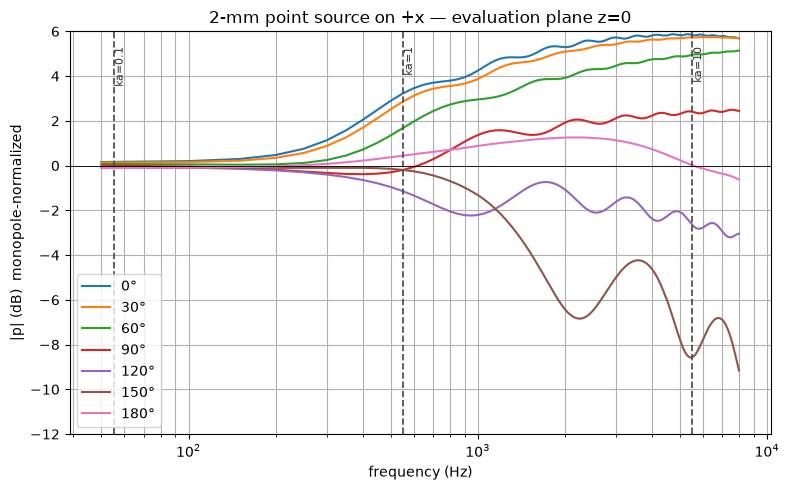

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


proj = Path(r"C:\Users\stefo\m2h_head\ICO_Sphere_HD20cm_sol10m_point_source_v1")
nodes_path = proj / "EvaluationGrids" / "UV_Sphere_10m" / "Nodes.txt"
be_root = proj / "NumCalc" / "source_1" / "be.out"

rho, v, r = 1.1839, 1.0, 10   # 10 meters ! 
#S = 2.199e-4/4
f0, df, nfreq = 50.0, 50.0, 160
angles = [0, 30, 60, 90, 120, 150, 180]

raw_n = nodes_path.read_text().strip().splitlines()
ndata = np.loadtxt(raw_n[1:])
gids, gxyz = ndata[:, 0].astype(int), ndata[:, 1:4]

def load_p(gid):
    freqs, p = [], []
    for i in range(1, nfreq + 1):
        pfile = be_root / f"be.{i}" / "pEvalGrid"
        data = np.loadtxt(pfile.read_text().splitlines()[3:])
        row = data[data[:, 0] == gid][0]
        freqs.append(f0 + (i - 1) * df)
        p.append(row[1] + 1j * row[2])
    return np.array(freqs), np.array(p)

plt.figure(figsize=(8, 5))
for deg in angles:
    phi = np.deg2rad(deg)
    target = np.array([r * np.cos(phi), r * np.sin(phi), 0.0])
    k = np.argmin(np.sum((gxyz - target) ** 2, axis=1))
    print(k)
    
    gid, xyz0 = int(gids[k]), gxyz[k]
    
    print(deg, "deg  gid", gid, "xyz", xyz0)
    
    freqs, p = load_p(gid)
    omega = 2 * np.pi * freqs
    #H = 4 * np.pi * r * p / (1j * omega * rho * v * S)
    #plt.semilogx(freqs, 20 * np.log10(np.abs(H)), label=f"{deg}°")
    plt.semilogx(freqs, 20 * np.log10(np.abs(p))+42, label=f"{deg}°")


c, a = 346.18, 0.1

ymin, ymax = plt.ylim()
for ka in (0.1, 1.0, 10.0):
    f = ka * c / (2 * np.pi * a)
    plt.axvline(f, color="0.3", ls="--", lw=1.25)
    plt.text(f, 0.8*ymax, f"  ka={ka:g}", rotation=90,
             va="top", ha="left", fontsize=8, color="0.2")
    
plt.axhline(0, color="k", lw=0.6)
plt.xlabel("frequency (Hz)")
plt.ylabel("|p| (dB)  monopole-normalized")
plt.title("2-mm point source on +x — evaluation plane z=0")
plt.grid(True, which="both")
plt.ylim(-12, 6)
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
i = 2   # 100 Hz
data = np.loadtxt((be_root / f"be.{i}" / "pEvalGrid").read_text().splitlines()[3:])
for deg in [0, 30, 60, 90, 120, 150, 180]:
    phi = np.deg2rad(deg)
    target = np.array([r*np.cos(phi), r*np.sin(phi), 0.0])
    k = np.argmin(((gxyz - target)**2).sum(axis=1))
    gid = int(gids[k])
    row = data[data[:, 0] == gid][0]
    p = row[1] + 1j*row[2]
    print(f"{deg:3d}  gid={gid}  xyz={gxyz[k]}  |p|={4*np.pi*abs(p):.4e}  "
          f"dB={20*np.log10(4*np.pi*abs(p))+19.82:.2f}")

  0  gid=200889  xyz=[10.  0.  0.]  |p|=1.0213e-01  dB=0.00
 30  gid=200895  xyz=[8.66025404 5.         0.        ]  |p|=1.0163e-01  dB=-0.04
 60  gid=200901  xyz=[5.         8.66025404 0.        ]  |p|=1.0045e-01  dB=-0.14
 90  gid=200907  xyz=[ 0. 10.  0.]  |p|=9.9316e-02  dB=-0.24
120  gid=200913  xyz=[-5.          8.66025404  0.        ]  |p|=9.8743e-02  dB=-0.29
150  gid=200919  xyz=[-8.66025404  5.          0.        ]  |p|=9.8670e-02  dB=-0.30
180  gid=200925  xyz=[-10.   0.   0.]  |p|=9.8715e-02  dB=-0.29


####  Point source at 1-mm from the surface - (x,y,z)=(0.101,0,0) m

889
0 deg  gid 200889 xyz [10.  0.  0.]
895
30 deg  gid 200895 xyz [8.66025404 5.         0.        ]
901
60 deg  gid 200901 xyz [5.         8.66025404 0.        ]
907
90 deg  gid 200907 xyz [ 0. 10.  0.]
913
120 deg  gid 200913 xyz [-5.          8.66025404  0.        ]
919
150 deg  gid 200919 xyz [-8.66025404  5.          0.        ]
925
180 deg  gid 200925 xyz [-10.   0.   0.]


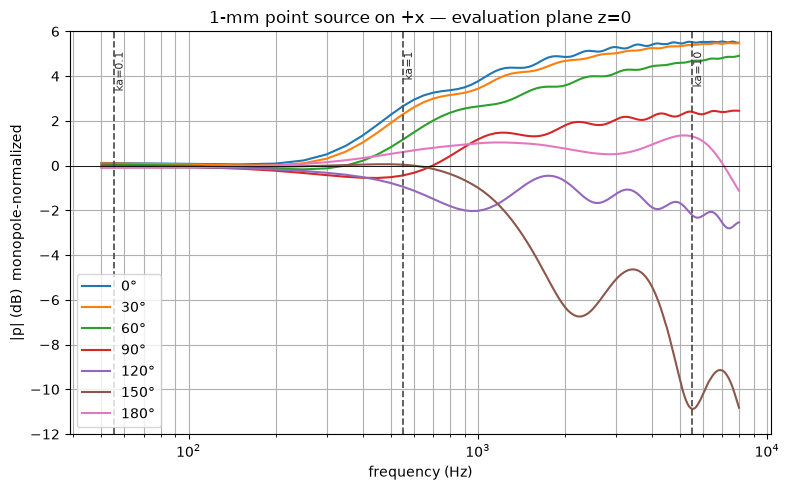

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path



proj = Path(r"C:\Users\stefo\m2h_head\ICO_Sphere_HD20cm_sol10m_point_source_v1")
nodes_path = proj / "EvaluationGrids" / "UV_Sphere_10m" / "Nodes.txt"
be_root = proj / "NumCalc" / "source_2" / "be.out"

c, a = 346.18, 0.1
rho, v, r = 1.1839, 1.0, 10   # 10 meters ! 
#S = 2.199e-4/4
f0, df, nfreq = 50.0, 50.0, 160
angles = [0, 30, 60, 90, 120, 150, 180]

raw_n = nodes_path.read_text().strip().splitlines()
ndata = np.loadtxt(raw_n[1:])
gids, gxyz = ndata[:, 0].astype(int), ndata[:, 1:4]


def load_p(gid):
    freqs, p = [], []
    for i in range(1, nfreq + 1):
        pfile = be_root / f"be.{i}" / "pEvalGrid"
        data = np.loadtxt(pfile.read_text().splitlines()[3:])
        row = data[data[:, 0] == gid][0]
        freqs.append(f0 + (i - 1) * df)
        p.append(row[1] + 1j * row[2])
    return np.array(freqs), np.array(p)

plt.figure(figsize=(8, 5))
for deg in angles:
    phi = np.deg2rad(deg)
    target = np.array([r * np.cos(phi), r * np.sin(phi), 0.0])
    k = np.argmin(np.sum((gxyz - target) ** 2, axis=1))
    print(k)
    
    gid, xyz0 = int(gids[k]), gxyz[k]
    
    print(deg, "deg  gid", gid, "xyz", xyz0)
    
    freqs, p = load_p(gid)
    omega = 2 * np.pi * freqs
    #H = 4 * np.pi * r * p / (1j * omega * rho * v * S)
    #plt.semilogx(freqs, 20 * np.log10(np.abs(H)), label=f"{deg}°")
    plt.semilogx(freqs, 20 * np.log10(np.abs(p))+42, label=f"{deg}°")


c, a = 346.18, 0.1

ymin, ymax = plt.ylim()
for ka in (0.1, 1.0, 10.0):
    f = ka * c / (2 * np.pi * a)
    plt.axvline(f, color="0.3", ls="--", lw=1.25)
    plt.text(f, 0.8*ymax, f"  ka={ka:g}", rotation=90,
             va="top", ha="left", fontsize=8, color="0.2")
    
plt.axhline(0, color="k", lw=0.6)
plt.xlabel("frequency (Hz)")
plt.ylabel("|p| (dB)  monopole-normalized")
plt.title("1-mm point source on +x — evaluation plane z=0")
plt.grid(True, which="both")
plt.ylim(-12, 6)
plt.legend()
plt.tight_layout()
plt.show()



In [27]:
i = 2   # 100 Hz
data = np.loadtxt((be_root / f"be.{i}" / "pEvalGrid").read_text().splitlines()[3:])
for deg in [0, 30, 60, 90, 120, 150, 180]:
    phi = np.deg2rad(deg)
    target = np.array([r*np.cos(phi), r*np.sin(phi), 0.0])
    k = np.argmin(((gxyz - target)**2).sum(axis=1))
    gid = int(gids[k])
    row = data[data[:, 0] == gid][0]
    p = row[1] + 1j*row[2]
    print(f"{deg:3d}  gid={gid}  xyz={gxyz[k]}  |p|={4*np.pi*abs(p):.4e}  "
          f"dB={20*np.log10(4*np.pi*abs(p))+19.82:.2f}")

  0  gid=200889  xyz=[10.  0.  0.]  |p|=1.0073e-01  dB=-0.12
 30  gid=200895  xyz=[8.66025404 5.         0.        ]  |p|=1.0044e-01  dB=-0.14
 60  gid=200901  xyz=[5.         8.66025404 0.        ]  |p|=9.9787e-02  dB=-0.20
 90  gid=200907  xyz=[ 0. 10.  0.]  |p|=9.9185e-02  dB=-0.25
120  gid=200913  xyz=[-5.          8.66025404  0.        ]  |p|=9.8912e-02  dB=-0.27
150  gid=200919  xyz=[-8.66025404  5.          0.        ]  |p|=9.8914e-02  dB=-0.27
180  gid=200925  xyz=[-10.   0.   0.]  |p|=9.8956e-02  dB=-0.27


### Dimensionless frequency ka  
Rigid sphere, a=0.1m, c=346.18m/s (NumCalc)

| f (Hz) | λ (m) | k (m−1) | ka |
|-----------:|----------------:|-------------------:|-------:|
| 100 | 3.462 | 1.815 | **0.18** |
| 500 | 0.692 | 9.075 | **0.91** |
| 1000 | 0.346 | 18.15 | **1.82** |
| 2000 | 0.173 | 36.30 | **3.63** |
| 4000 | 0.087 | 72.60 | **7.26** |
| 8000 | 0.043 | 145.2 | **14.52** |

Low ka: near-monopole after piston correction.  
ka≳1: scattering onsets.  
ka≈14.5: short-wavelength regime (pole mesh still untrusted).